# Preliminaries

In [52]:
# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline
from matplotlib import colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d

# numerics
import numpy as np
from scipy.integrate import solve_bvp, trapezoid, quad, dblquad


In [53]:
control = 'pressure'  # 'flow' or 'pressure'

In [54]:
# imaginary unit shortcut
I = sp.I
# define I^(3/2) once for convenience since we use it a lot
I3half = I**sp.Rational(3, 2)

# symbols needed to define the problem
kappa, f0 = sp.symbols('kappa f0')
Wo, Gm, Th = sp.symbols('Wo Gm Th', positive=True)
Y, Z, T = sp.symbols('Y Z T', positive=True)

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# Streaming flux via perturbation solution of EHD problem

Method of Zhang &amp; Rallabandi (2024), as implemented by Rade, Pande &amp; Christov (2025)

Leading-order pressure phasor is
$$
    P_{0}(Z) = \frac{\sinh\big(\kappa(1-Z)\big)}{\sinh \kappa} e^{iT},
$$
for pressure control, or
$$
    P_{0}(Z) = \frac{\sinh\big(\kappa(1-Z)\big)}{\mathfrak{f}_0(Wo) \kappa \cosh \kappa} e^{iT},
$$
for flow-rate control.

In both cases,
\begin{align*}
    \kappa(Wo,\gamma,\theta) &:= \sqrt{\frac{i\gamma}{\mathfrak{f}_0(Wo) + i \theta \gamma}},\\
    \mathfrak{f}_0(Wo) &:= \frac{1}{i Wo^2}\left[1 - \frac{1}{i^{3/2}{Wo}/2}\tan\left(i^{3/2}{Wo}/2\right)\right].
\end{align*}

In [55]:
if control == 'pressure':
    P0a = sp.sinh(kappa*(1 - Z)) / sp.sinh(kappa)
elif control == 'flow':
    P0a = sp.sinh(kappa*(1 - Z)) / (kappa*sp.cosh(kappa))
else:
    raise ValueError("control must be 'pressure' or 'flow'")

P0 = P0a * sp.exp(I*T)

The leading-rder vertical displacement phasor is
$$
    U_{Y,0}(Z) = P_0 - \theta \frac{d^2 P_0}{d Z^2},
    %\left(\frac{\mathfrak{f}_0}{i \gamma}\right) \frac{d^2 P_{0}}{d Z^2} = \left(\frac{\mathfrak{f}_0}{i \gamma}\right) \kappa^2 P_{0}(Z). 
$$
which we compute symbolically.

In [56]:
U0 = P0 - Th*sp.diff(P0, Z, 2)

The leading-order axial velocity phasor is
$$
    V_{Z,0}(Y,Z) = 
    \frac{1}{i{Wo}^2}\left[1-\frac{\cos\left(i^{3/2} (1-2Y){Wo}/2\right)}{\cos\left(i^{3/2} {Wo}/2 \right)}\right] \left( -\frac{d P_{0}}{d Z} \right) e^{iT},
$$

In [57]:
Vz0a = (1/(I*Wo**2)) * (1 - sp.cos(I3half*(1 - 2*Y)*Wo/2) / sp.cos(I3half*Wo/2)) * (-sp.diff(P0a, Z))
Vz0 = Vz0a * sp.exp(I*T)

We solve for the leading-order vertical velocity from the continuity equation as an ODE:
$$
    \frac{\partial V_{Y,0}}{\partial Y} = - \frac{\partial V_{Z,0}}{\partial Z},\quad V_{Y,0}|_{Y=0} = 0.
$$

In [58]:
f = sp.Function('f')
ode = sp.Eq(sp.diff(f(Y), Y) + sp.diff(Vz0a, Z), 0)
Vy0a = sp.dsolve(ode, ics={f(0): 0}).rhs           # symbolic in (Y,Z)
Vy0 = Vy0a * sp.exp(I*T)

The streaming flow rate is
$$
    \langle Q_1 \rangle = \underbrace{\int_0^1 -\frac{1}{2} \underbrace{\left.\left\langle U_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} \right|_{Y=1}\right\rangle}_{\mathrm{slip}} \, dY}_{I_1} + \underbrace{\int_0^1 \int_0^1 \widetilde{\langle V_{Z,1} \rangle} \, dY dZ}_{I_2},
$$
for pressure control, or
$$
    \langle Q_1 \rangle = 0,
$$
for flow-rate control.

Here, $\widetilde{\langle V_{Z,1}\rangle}$ satsifies the BVP
$$
    \frac{Wo^2}{\gamma} \Bigg( \underbrace{\left\langle V_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} \right\rangle}_{\mathrm{term1}} + \underbrace{\left\langle V_{Z,0} \frac{\partial V_{Z,0}}{\partial Z} \right\rangle}_{\mathrm{term2}} \Bigg) = \frac{\partial^2 \widetilde{\langle V_{Z,1} \rangle}}{\partial Y^2},\qquad \widetilde{\langle V_{Z,1} \rangle}|_{Y=0} = \widetilde{\langle V_{Z,1} \rangle}|_{Y=1} = 0.
$$

Recall that, for two phasors $A = A_a e^{i T}$ and $B = B_a e^{i T}$, $\langle A B \rangle = \tfrac{1}{2}\mathrm{Re}[A_a^*B_a] = \tfrac{1}{2}\mathrm{Re}[A_aB_a^*]$, where the star superscript denotes the complex conjugate.

In [74]:
# define the expressions for kappa and f0
kappa_expr = sp.sqrt(I*Gm/(f0 + Th*I*Gm))
f0_expr = (-I*Wo - 2*I3half*sp.tan(I3half*Wo/2)) / Wo**3

# pre-compute the advective term < > averages
# (1/2)*Re(conj(Vy0)*dVz0/dY)
term1 = sp.Rational(1, 2) * sp.re(sp.conjugate(Vy0) * sp.diff(Vz0, Y))
term1 = term1.subs({kappa: kappa_expr}).subs({f0: f0_expr})
# (1/2)*Re(conj(Vz0)*dVz0/dZ)
term2 = sp.Rational(1, 2) * sp.re(sp.conjugate(Vz0) * sp.diff(Vz0, Z))
term2 = term2.subs({kappa: kappa_expr}).subs({f0: f0_expr})

# pre-compute the effectivel slip term < > average
# (1/2)*Re(conj(U0)*(dVz0/dY at Y=1))
slip = sp.Rational(1, 2) * sp.re(sp.conjugate(U0) * sp.diff(Vz0, Y).subs({Y: 1}))
slip = slip.subs({kappa: kappa_expr}).subs({f0: f0_expr})

# time factor cancels in the (1/2)*Re(...) products; 
# set T=0 to simplify numeric lambdification
# === why doesn't it simplify on its own and T drop out???? ===
# term1 = (term1.subs({T: 0}))
# term2 = (term2.subs({T: 0}))
slip = (slip.subs({T: 0}))

Pick parameter values for $Wo,\gamma,\theta$.

In [75]:
Wo_val = 5
Gm_val = 0.1
Th_val = 0.0014

1. Compute the first integral in streaming flow rate, which is the same under both approaches.

In [76]:
I1_integrand_num = sp.lambdify((Z, Wo, Gm, Th), -0.5 * slip, modules=['numpy'])
# use 'quad' double integral
I1_out = quad(I1_integrand_num, 0, 1, args=(Wo_val, Gm_val, Th_val,))
# grab first output element (which is the integral value)
I1 = I1_out[0]

2. Solve the BVP for $\widetilde{\langle V_{Z,1}\rangle}$ numerically.

In [62]:
LHS_expr = (Wo**2/Gm) * (term1 + term2)
# build LHS (parameterized), no numeric substitution here;
# keep symbolic in Wo, Gm, Th for lambdification
LHS_num = sp.lambdify((Y, Z, Wo, Gm, Th), LHS_expr, modules=['numpy'])

def I2_ODE_compute(Wo_val, Gm_val, Th_val, verb):
    # generate meshes
    zmesh = np.linspace(0.0, 1.0, 100)
    ymesh = np.linspace(0.0, 1.0, 100)

    # storage for integral over Y of Vz1_adv
    yint_Vz1_adv = np.zeros_like(zmesh, dtype=float)

    # initial mesh/guess for solve_bvp
    y_init = ymesh
    y_guess = np.vstack([y_init*(1.0 - y_init), 1.0 - 2.0*y_init])  # shape (2, m)

    # loop over Z to solve BVP at each Z
    # and build integral over Y as a function of Z
    for i, z in enumerate(zmesh):
        # RHS function generated on-the-fly for current Z
        def fun(y, U):
            # U[0] = Vz1_adv, U[1] = d Vz1_adv/d Y
            rhs = LHS_num(y, z, Wo_val, Gm_val, Th_val)
            return np.vstack([U[1], rhs])

        # homogeneous Dirichlet BCs
        def bc(Ua, Ub):
            return np.array([Ua[0], Ub[0]])

        sol = solve_bvp(fun, bc, y_init, y_guess, tol=1e-6, verbose=verb)

        if sol.status != 0:
            ErrorMsg = f"WARNING: BVP solver failed at z={z:.4f} with message: {sol.message}."
            print(ErrorMsg)
            
        # integrate over Y
        yint_Vz1_adv[i] = trapezoid(sol.y[0], sol.x)

    # integrate over Z
    return trapezoid(yint_Vz1_adv, zmesh)

I2_ODE = I2_ODE_compute(Wo_val, Gm_val, Th_val, 1)

Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 4.97e-07 
Maximum boundary residual: 3.60e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.05e-07 
Maximum boundary residual: 5.26e-17
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.14e-07 
Maximum boundary residual: 1.11e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.23e-07 
Maximum boundary residual: 2.86e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.34e-07 
Maximum boundary residual: 1.20e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.46e-07 
Maximum boundary residual: 3.48e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.59e-07 
Maximum boundary residual: 2.26e-16
Solved in 1 iterations, number of nodes 100. 
Maximum relative residual: 5.74e-07 
Maximum boundary residual: 2.54e-16
Solved in 1 iterations, number of nodes 100. 
Ma

# Streaming flux via the RT

Now, the streaming flux is given by
\begin{align*}
  \langle Q_1 \rangle = Q_{1,0,a}|_{Z=0}
    &= \underbrace{\int_0^1 -\frac{1}{2}\left\langle \left.\frac{\partial V_{Z,0}}{\partial Y}\right|_{Y=1} U_{Y,0} \right\rangle \, d Z}_{I_1} \\
    &\phantom{=}
    \underbrace{\int_0^1 \int_0^1 - \frac{Wo^2}{\gamma} \left[ \left\langle V_{Y,0} \frac{\partial V_{Z,0}}{\partial Y} \right\rangle + \left\langle V_{Z,0} \frac{\partial V_{Z,0}}{\partial Z} \right\rangle \right] \hat{V}_Z \, d Y d Z}_{I_2},
\end{align*}
where we recognize the first term is as above.

The "hat" problem is:
$$
  \hat{V}_Z(Y) = \frac{1}{2}Y(1-Y),\qquad \hat{P}(Z) = 1-Z.
$$

In [12]:
# hat problem (given)
VzHat = (1 - Y)*Y/2
PHat = 1 - Z
QHat = sp.Rational(1, 12)  # not used below but kept for completeness

In [ ]:
# integrand for the double integral dY dZ
RT_integrand_expr =  - ( (Wo**2/Gm) * (term1+term2) ) * VzHat

# don't try using SymPy -- takes too long
#sp.integrate(RT_integrand_expr, (Y,0,1), (Z,0,1))

In [ ]:
# using SciPy
# no numeric substitution here; keep symbolic in Wo, Gm, Th for lambdification
RT_integrand_num = sp.lambdify((Y, Z, Wo, Gm, Th), RT_integrand_expr, modules=['numpy'])

# use 'quad' double integral
I2_RT_out = dblquad(RT_integrand_num, 0, 1, 0, 1, args=(Wo_val, Gm_val, Th_val,))
# grab first output element (which is the integral value)
I2_RT = I2_RT_out[0]

# ALTERNATIVE: discretize Y and Z to use trapezoid
# using ij indexing so arr[z, y] matches (Z, Y) order
# ZZ, YY = np.meshgrid(zmesh, ymesh, indexing='ij')
# RT_vals = RT_integrand_num(YY, ZZ, Wo_val, Gm_val, Th_val)  # pass Y first, Z second
# I2_RT = trapezoid(trapezoid(RT_vals, ymesh, axis=1), zmesh, axis=0)

In [78]:
print("I2_ODE =", I2_ODE)
print("I2_RT  =", I2_RT, "with error estimate", I2_RT_out[1])
print("I1     = ", I1,   "with error estimate", I1_out[1])

I2_ODE = -0.02845462443237774
I2_RT  = -0.028460959714756453 with error estimate 6.182276302903391e-16
I1     =  0.026611540079422537 with error estimate 2.954474451691007e-16


# Loop over many Womersley numbers

Pick parameter values for $Wo,\gamma,\theta$.

In [ ]:
def compute_Q1_of_Wo(Wo_vals, Gm_val, Th_val):
    # initialize arrays to store results
    I1_vals = np.zeros_like(Wo_vals)
    I2_RT_vals = np.zeros_like(Wo_vals)
    I2_ODE_vals = np.zeros_like(Wo_vals)

    # loop over Womersley numbers
    for idx, Wo_curr in enumerate(Wo_vals):
        print("--------------------------------------------------")
        print(f"Processing Wo = {Wo_curr:.2f} (value {idx+1} of {len(Wo_vals)})")
        print("--------------------------------------------------")

        # compute I1
        I1_out_curr = quad(I1_integrand_num, 0, 1, args=(Wo_curr, Gm_val, Th_val,))
        print(f"I1     = {I1_out_curr[0]:.6e} with error estimate {I1_out_curr[1]:.6e}")
        I1_vals[idx] = I1_out_curr[0]
            
        # compute I2_RT
        I2_RT_out_curr = dblquad(RT_integrand_num, 0, 1, 0, 1, args=(Wo_curr, Gm_val, Th_val,))
        print(f"I2_RT  = {I2_RT_out_curr[0]:.6e} with error estimate {I2_RT_out_curr[1]:.6e}")
        I2_RT_vals[idx] = I2_RT_out_curr[0]
        
        # compute I2_ODE
        I2_ODE_vals[idx] = I2_ODE_compute(Wo_curr, Gm_val, Th_val, 0)
        print(f"I2_ODE = {I2_ODE_vals[idx]:.6e}")

    #  total streaming flux
    Q1_ODE = I1_vals + I2_ODE_vals
    Q1_RT = I1_vals + I2_RT_vals

    return Q1_ODE, Q1_RT

In [38]:
Wo_vals = np.linspace(1e-3, 15, 60)
Gm_vals = np.array([0.01, 0.1, 1], dtype=float)
Th_val = 0.0014

In [39]:
Q1_ODE_1, Q1_RT_1 = compute_Q1_of_Wo(Wo_vals, Gm_vals[0], Th_val)

--------------------------------------------------
Processing Wo = 0.00 (value 1 of 60)
--------------------------------------------------
I1 = 6.249979e-02 with error estimate 6.938870e-16
I2_RT = 8.184042e-11 with error estimate 2.878720e-11
I2_ODE = 8.180678e-11
--------------------------------------------------
Processing Wo = 0.26 (value 2 of 60)
--------------------------------------------------
I1 = 6.250449e-02 with error estimate 6.939392e-16
I2_RT = 3.538424e-06 with error estimate 1.933558e-19
I2_ODE = 3.538580e-06
--------------------------------------------------
Processing Wo = 0.51 (value 3 of 60)
--------------------------------------------------
I1 = 6.249226e-02 with error estimate 6.938035e-16
I2_RT = -6.573995e-06 with error estimate 3.125967e-19
I2_ODE = -6.571230e-06
--------------------------------------------------
Processing Wo = 0.76 (value 4 of 60)
--------------------------------------------------
I1 = 6.238501e-02 with error estimate 6.926127e-16
I2_RT = -9

In [40]:
Q1_ODE_2, Q1_RT_2 = compute_Q1_of_Wo(Wo_vals, Gm_vals[1], Th_val)

--------------------------------------------------
Processing Wo = 0.00 (value 1 of 60)
--------------------------------------------------
I1 = 6.247909e-02 with error estimate 6.936573e-16
I2_RT = 8.081337e-10 with error estimate 2.852576e-10
I2_ODE = 8.078038e-10
--------------------------------------------------
Processing Wo = 0.26 (value 2 of 60)
--------------------------------------------------
I1 = 6.254519e-02 with error estimate 6.943911e-16
I2_RT = 5.045287e-05 with error estimate 2.260511e-18
I2_ODE = 5.045286e-05
--------------------------------------------------
Processing Wo = 0.51 (value 3 of 60)
--------------------------------------------------
I1 = 6.271729e-02 with error estimate 6.963018e-16
I2_RT = 1.811961e-04 with error estimate 8.562992e-18
I2_ODE = 1.811980e-04
--------------------------------------------------
Processing Wo = 0.76 (value 4 of 60)
--------------------------------------------------
I1 = 6.291971e-02 with error estimate 6.985492e-16
I2_RT = 3.32

In [41]:
Q1_ODE_3, Q1_RT_3 = compute_Q1_of_Wo(Wo_vals, Gm_vals[2], Th_val)

--------------------------------------------------
Processing Wo = 0.00 (value 1 of 60)
--------------------------------------------------
I1 = 6.147592e-02 with error estimate 6.825198e-16
I2_RT = 3.958305e-09 with error estimate 1.790846e-09
I2_ODE = 3.957126e-09
--------------------------------------------------
Processing Wo = 0.26 (value 2 of 60)
--------------------------------------------------
I1 = 6.180664e-02 with error estimate 6.861915e-16
I2_RT = 2.552621e-04 with error estimate 1.438825e-17
I2_ODE = 2.552890e-04
--------------------------------------------------
Processing Wo = 0.51 (value 3 of 60)
--------------------------------------------------
I1 = 6.279371e-02 with error estimate 6.971502e-16
I2_RT = 1.016945e-03 with error estimate 5.687011e-17
I2_ODE = 1.017048e-03
--------------------------------------------------
Processing Wo = 0.76 (value 4 of 60)
--------------------------------------------------
I1 = 6.443548e-02 with error estimate 7.153775e-16
I2_RT = 2.28

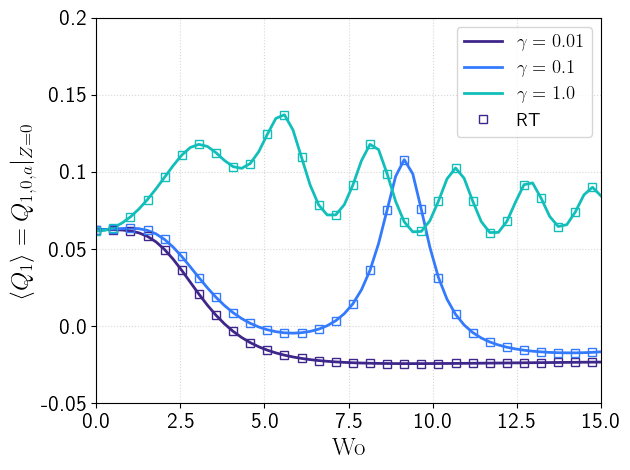

In [80]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$\mathrm{Wo}$')
ax.set_xlim(0, 15)
ax.set_ylabel(r'$\langle Q_1 \rangle = Q_{1,0,a}|_{Z=0}$')
ax.set_ylim(-0.05, 0.2)
#ax.set_aspect('equal', 'box')
ax.grid(alpha=0.5, linestyle='dotted')

ax.plot(Wo_vals, Q1_ODE_1, color=(62/255, 38/255, 138/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[0]}$')
ax.plot(Wo_vals, Q1_ODE_2, color=(51/255, 122/255, 253/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[1]}$')
ax.plot(Wo_vals, Q1_ODE_3, color=(18/255, 190/255, 185/255), linewidth=2,
        label=fr'$\gamma={Gm_vals[2]}$')
# skip some values for RT to avoid overplotting
ax.plot(Wo_vals[::2], Q1_RT_1[::2], label='RT',
        color=(62/255, 38/255, 138/255), linestyle='', marker='s', fillstyle='none')
ax.plot(Wo_vals[::2], Q1_RT_2[::2],
        color=(51/255, 122/255, 253/255), linestyle='', marker='s', fillstyle='none')
ax.plot(Wo_vals[::2], Q1_RT_3[::2],
        color=(18/255, 190/255, 185/255), linestyle='', marker='s', fillstyle='none')

ax.legend()

# font hack for ticks labels when using LaTeX fonts
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([str(round(x,4)) for x in xticks])

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([str(round(y,4)) for y in yticks])

plt.show()

#fig.savefig('Q1_vs_Wo_EHD_RT.pdf')